In [49]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [50]:
df = pd.read_csv('gld_price_data.csv')
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


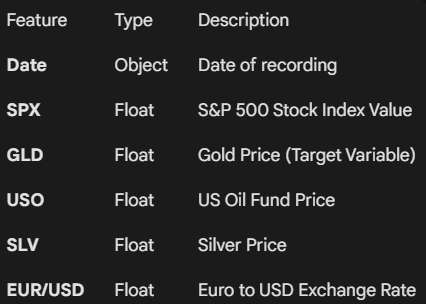

In [51]:
df.shape

(2290, 6)

In [52]:
df.info()  # no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [53]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [54]:
df['Date'] = pd.to_datetime(df['Date'])

In [55]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


Text(0.5, 1.0, 'Correlation Heatmap')

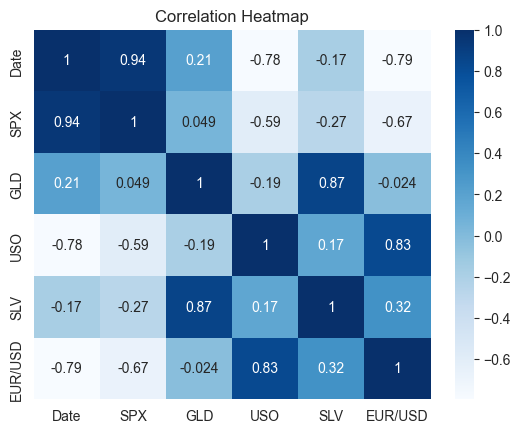

In [56]:
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')

In [57]:
correlation['GLD']  # gold & silver prices are highly correlated. 

Date       0.209118
SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64

Text(0.5, 0, 'Gold Price')

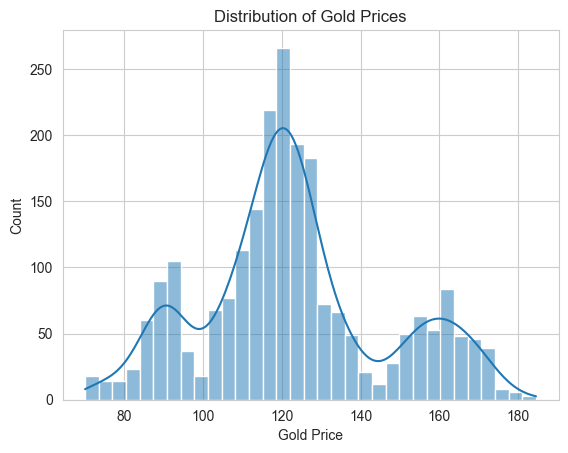

In [58]:
sns.set_style('whitegrid')
sns.histplot(df['GLD'], kde=True)
plt.title('Distribution of Gold Prices')
plt.xlabel('Gold Price')

Text(0.5, 0.98, 'Gold vs Silver Prices')

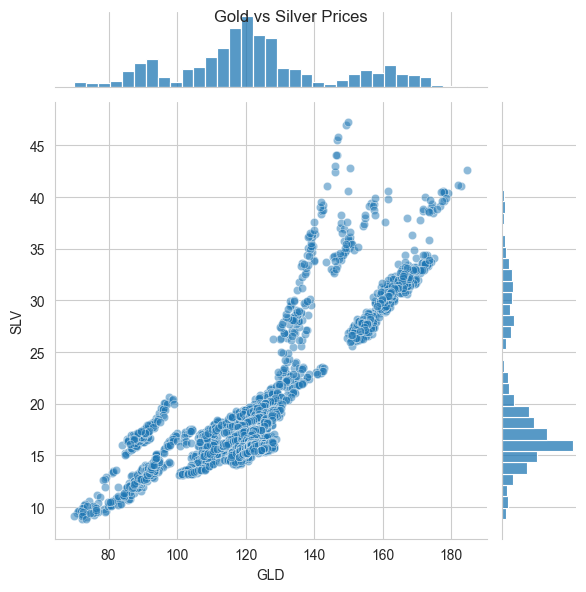

In [59]:
sns.jointplot(x='GLD', y='SLV', data=df, kind='scatter', alpha=0.5)
plt.suptitle('Gold vs Silver Prices')

In [60]:
X = df.drop(['GLD', 'Date'], axis=1)
y = df['GLD']

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [64]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
y_pred_lr = lr.predict(X_test_scaled)

In [66]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print('R2 Score:', r2_score(y_test, y_pred_lr))
print('MSE:', mean_squared_error(y_test, y_pred_lr))
print('MAE:', mean_absolute_error(y_test, y_pred_lr))

R2 Score: 0.8975640982991402
MSE: 56.165594215006
MAE: 5.695900644269288


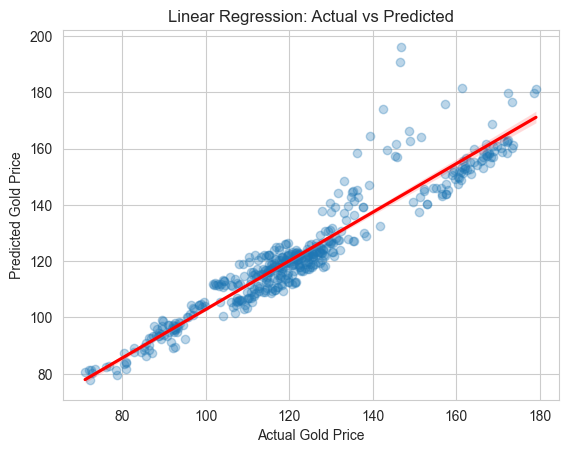

In [67]:
sns.regplot(x=y_test, y=y_pred_lr, line_kws={'color': 'red'}, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Gold Price')
plt.ylabel('Predicted Gold Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

- between the prices 80-140, the model is quite accurate.
- after 140, the predictions are a bit off.
- some outliers too exist after 140.

In [ ]:
training_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)
print('Training R2 Score:', training_score)
print('Test R2 Score:', test_score)

Training R2 Score: 0.8771892526181604
Test R2 Score: 0.8975640982991402


slight underfitting, but overall model is performing decently.

using RandomForestRegressor to improve performance. 

(it can handle outliers better.)

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}

In [72]:
rf = RandomForestRegressor(random_state=42)
grid = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='r2', cv=5)
grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [73]:
print("Best Hyperparameters:", grid.best_params_)
best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
print('Random Forest R2 Score:', r2_score(y_test, y_pred_rf))

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest R2 Score: 0.9903974027541166


r2 score improved from 0.895 to 0.990

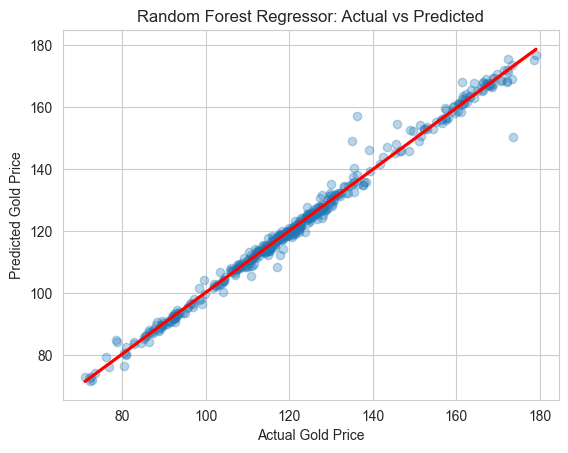

In [74]:
sns.regplot(x=y_test, y=y_pred_rf, line_kws={'color': 'red'}, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Gold Price')
plt.ylabel('Predicted Gold Price')
plt.title('Random Forest Regressor: Actual vs Predicted')
plt.show()

prediction accuracy improved!

feature importance

In [77]:
importances = best_rf.feature_importances_
features = X.columns

In [79]:
feature_df = pd.DataFrame({
    'Feature': features, 
    'Importance': importances
})
feature_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_df

,Feature,Importance
2,SLV,0.763615
0,SPX,0.174328
1,USO,0.035137
3,EUR/USD,0.026920


- SLV: High (76%). The "Main factor" of the model.
- SPX: Moderate (17%). A secondary supporting factor.
- USO / EUR/USD: Low (<4%)Minimal impact; potentially redundant.

C:\Users\Mrunmayee Potdar\AppData\Local\Temp\ipykernel_18564\1060334024.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data = feature_df, palette='Set2')


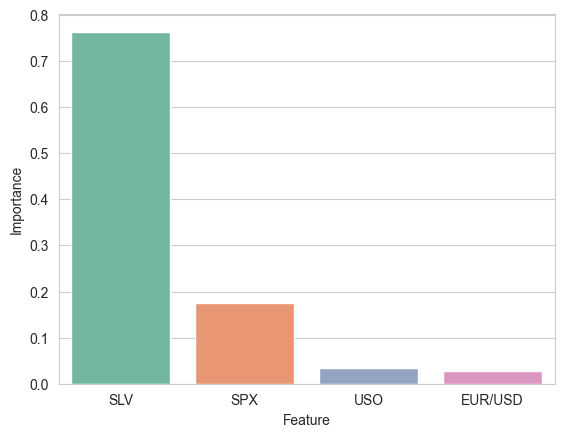

In [80]:
sns.barplot(x='Feature', y='Importance', data = feature_df, palette='Set2')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

predictions--

In [83]:
def predict_gold_price():
    print("Gold Price prediction tool")
    try:
        spx = float(input("Enter S&P 500 Index (SPX): "))
        uso = float(input("Enter US Oil Fund (uso): "))
        slv = float(input("Enter Silver Price (slv): "))
        eur_usd = float(input("Enter EUR/USD exchange rate: "))
        inputs = pd.DataFrame([[spx, uso, slv, eur_usd]], columns=['SPX', 'USO', 'SLV', 'EUR/USD'])
        scaled_inputs = sc.transform(inputs)
        pred = best_rf.predict(scaled_inputs)
        print("spx: ", spx, "uso: ", uso, "slv: ", slv, "eur_usd: ", eur_usd)
        print("Predicted Gold Price: ", pred[0])
    except ValueError:
        print("Invalid input!! Please enter valid numeric values only.")

predict_gold_price()

Gold Price prediction tool
spx:  1350.5 uso:  72.1 slv:  16.5 eur_usd:  1.45
Predicted Gold Price:  89.74734993500002


Conclusion--

- Model Comparison: The project successfully transitioned from a Linear Regression baseline (R^2: 0.897) to an optimized Random Forest Regressor ($R^2$: 0.990).
- Optimization: Using GridSearchCV to tune hyperparameters (specifically n_estimators=200) allowed the model to capture complex, non-linear relationships that the linear model missed.
- Key Drivers: Silver (SLV) and the EUR/USD exchange rate were identified as the most influential features in determining Gold prices. 
- Technical Integrity: By implementing a strict Split-then-Scale pipeline, the project ensures no data leakage and maintains high predictive reliability for new market inputs.